In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "../data/raw/ed_arrivals.csv"
df = pd.read_csv(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.head()

,timestamp,arrivals,day_of_week,is_weekend,is_holiday,hour
0,2026-01-01 00:00:00,3,Thursday,0,1,0
1,2026-01-01 01:00:00,2,Thursday,0,1,1
2,2026-01-01 02:00:00,3,Thursday,0,1,2
3,2026-01-01 03:00:00,4,Thursday,0,1,3
4,2026-01-01 04:00:00,2,Thursday,0,1,4


In [3]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

Number of rows: 8760
Number of columns: 6

Columns:
['timestamp', 'arrivals', 'day_of_week', 'is_weekend', 'is_holiday', 'hour']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    8760 non-null   datetime64[ns]
 1   arrivals     8760 non-null   int64         
 2   day_of_week  8760 non-null   object        
 3   is_weekend   8760 non-null   int64         
 4   is_holiday   8760 non-null   int64         
 5   hour         8760 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 410.8+ KB


In [5]:
df.shape

(8760, 6)

In [7]:
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values found:")
    print(missing_values[missing_values > 0])

No missing values found.


In [8]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [9]:
duplicate_timestamps = df["timestamp"].duplicated().sum()

print("Duplicate timestamps:", duplicate_timestamps)

Duplicate timestamps: 0


In [10]:
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

Start: 2026-01-01 00:00:00
End: 2026-12-31 23:00:00


In [11]:
expected_timestamps = pd.date_range(
    start=df["timestamp"].min(),
    end=df["timestamp"].max(),
    freq="h"
)

missing_timestamps = expected_timestamps.difference(
    df["timestamp"]
)

print("Expected timestamps:", len(expected_timestamps))
print("Actual timestamps:", len(df))
print("Missing timestamps:", len(missing_timestamps))

Expected timestamps: 8760
Actual timestamps: 8760
Missing timestamps: 0


In [12]:
df["arrivals"].describe()

count    8760.000000
mean        6.563584
std         3.115257
min         0.000000
25%         4.000000
50%         7.000000
75%         9.000000
max        16.000000
Name: arrivals, dtype: float64

In [13]:
negative_arrivals = (df["arrivals"] < 0).sum()

print("Negative arrival values:", negative_arrivals)

Negative arrival values: 0


In [14]:
non_integer_arrivals = (
    df["arrivals"] % 1 != 0
).sum()

print("Non-integer arrival values:", non_integer_arrivals)

Non-integer arrival values: 0


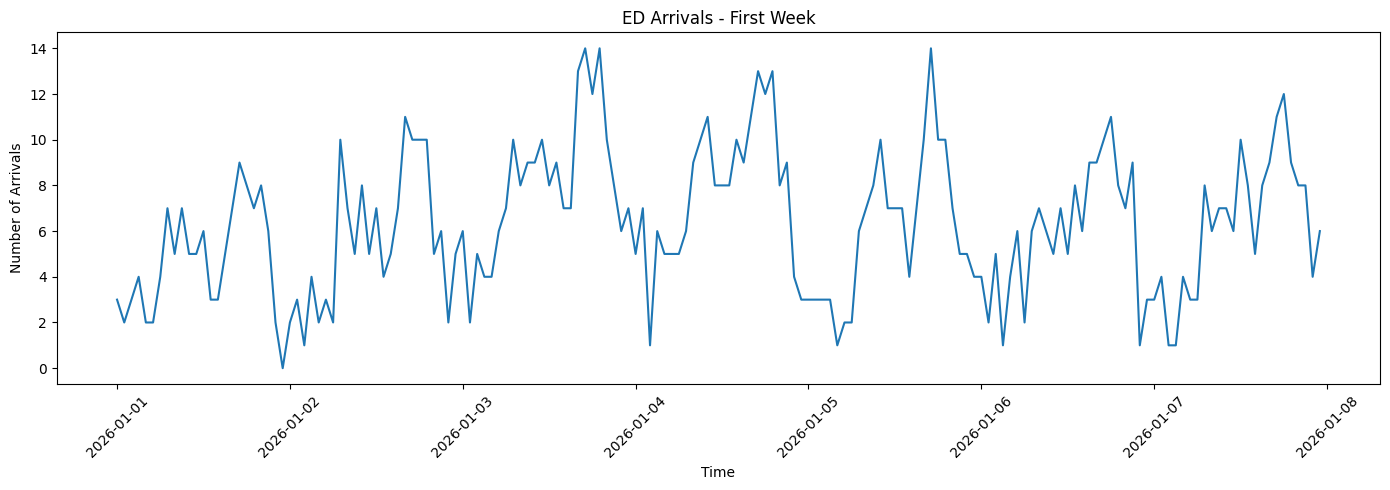

In [15]:
first_week = df.head(24 * 7)

plt.figure(figsize=(14, 5))

plt.plot(
    first_week["timestamp"],
    first_week["arrivals"],
)

plt.title("ED Arrivals - First Week")
plt.xlabel("Time")
plt.ylabel("Number of Arrivals")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

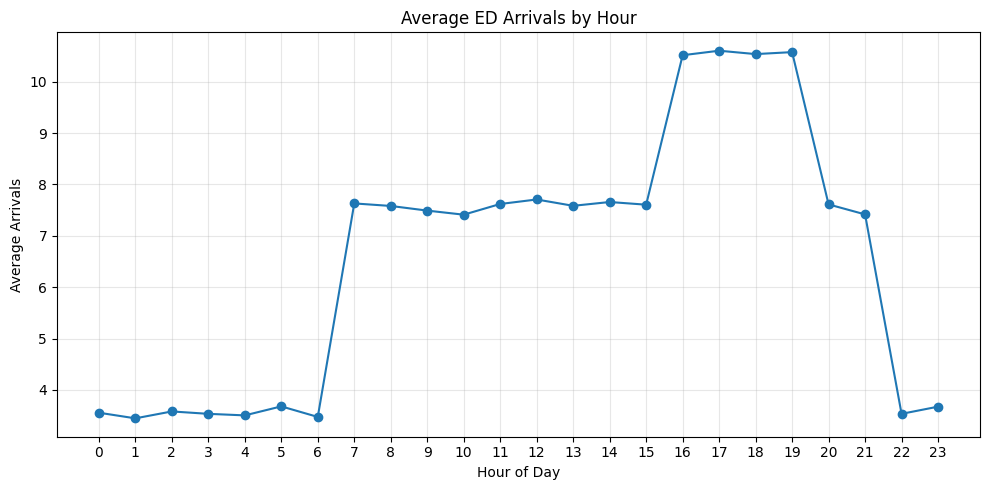

In [16]:
hourly_average = (
    df.groupby("hour")["arrivals"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_average.index,
    hourly_average.values,
    marker="o",
)

plt.title("Average ED Arrivals by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Arrivals")

plt.xticks(range(24))

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

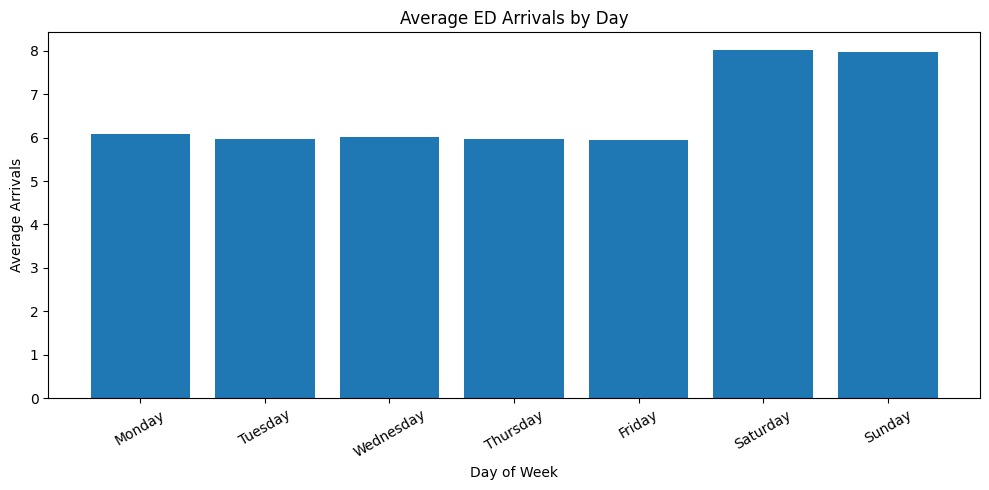

In [17]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

daily_average = (
    df.groupby("day_of_week")["arrivals"]
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))

plt.bar(
    daily_average.index,
    daily_average.values,
)

plt.title("Average ED Arrivals by Day")
plt.xlabel("Day of Week")
plt.ylabel("Average Arrivals")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

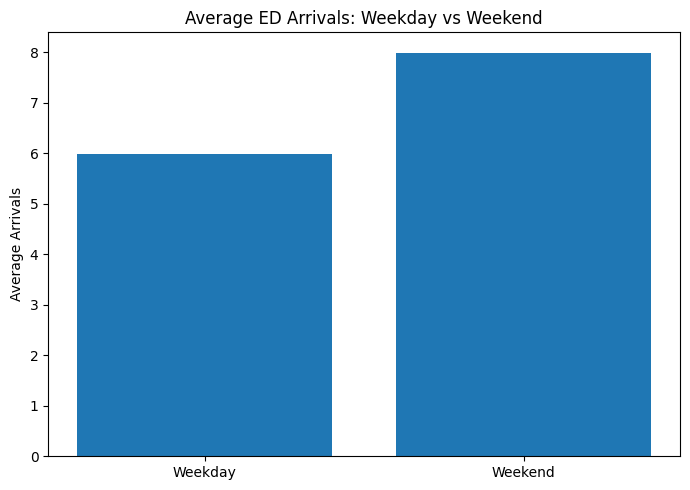

In [18]:
weekend_average = (
    df.groupby("is_weekend")["arrivals"]
    .mean()
)

weekend_average.index = [
    "Weekday",
    "Weekend",
]

weekend_average

plt.figure(figsize=(7, 5))

plt.bar(
    weekend_average.index,
    weekend_average.values,
)

plt.title("Average ED Arrivals: Weekday vs Weekend")
plt.ylabel("Average Arrivals")

plt.tight_layout()
plt.show()

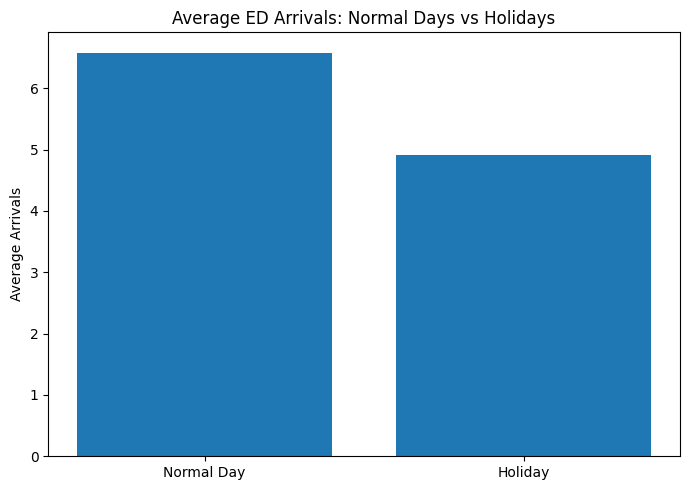

In [19]:
holiday_average = (
    df.groupby("is_holiday")["arrivals"]
    .mean()
)

holiday_average.index = [
    "Normal Day",
    "Holiday",
]

holiday_average
plt.figure(figsize=(7, 5))

plt.bar(
    holiday_average.index,
    holiday_average.values,
)

plt.title("Average ED Arrivals: Normal Days vs Holidays")
plt.ylabel("Average Arrivals")

plt.tight_layout()
plt.show()

In [20]:
print("========== DATA QUALITY SUMMARY ==========")

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate timestamps: {df['timestamp'].duplicated().sum()}")
print(f"Negative arrivals: {(df['arrivals'] < 0).sum()}")

print(
    f"Time range: "
    f"{df['timestamp'].min()} → {df['timestamp'].max()}"
)

print(
    f"Average hourly arrivals: "
    f"{df['arrivals'].mean():.2f}"
)

print(
    f"Maximum hourly arrivals: "
    f"{df['arrivals'].max()}"
)

========== DATA QUALITY SUMMARY ==========
Rows: 8,760
Columns: 6
Missing values: 0
Duplicate rows: 0
Duplicate timestamps: 0
Negative arrivals: 0
Time range: 2026-01-01 00:00:00 → 2026-12-31 23:00:00
Average hourly arrivals: 6.56
Maximum hourly arrivals: 16
